# Example: thermal spice fitting
This examples uses UC Merced shading IVs to develop the cell temperature simulation

In [1]:
import os
from pathlib import Path

project_root = Path.cwd().parents[1]
os.chdir(project_root)   # now cwd is .../pvcracks

from pvcracks.pvspice.spice_tools import run_ngspice
from pvcracks.pvspice.spice_tools import ngpsice_read_voltage_current_modules
from pvcracks.pvspice.spice_tools import module_to_netlist

spicepath = "/home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice" #kahunaimport numpy as np
import pandas as pd
import pvlib

In [2]:
project_root

PosixPath('/home/nrjost/githome/pvcracks')

In [3]:
ivdata = pd.read_csv("docs/data/IVshaded/Data.csv")
ivdata.dtypes

Date_Time                        object
Irradiance_61                   float64
Voltage                          object
Current                          object
Amb_Temp                        float64
wind_speed                      float64
Observed_Temp of Shaded Cell    float64
Bias_V                            int64
Reverse_Bias_I (Shaded Cell)    float64
Reverse_Bias_V (Shaded Cell)    float64
Shade_Percentage                float64
Middle_Temp                     float64
dtype: object

In [4]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Make a copy so the original dataframe is unchanged
iv = ivdata.copy()

# Parse Date_Time
iv["Date_Time"] = pd.to_datetime(iv["Date_Time"], errors="coerce")

# Function to convert string-list cells into numpy arrays
def parse_array_cell(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return np.array(x, dtype=float)

    if pd.isna(x):
        return np.array([])

    s = str(x).strip()

    try:
        return np.array(ast.literal_eval(s), dtype=float)
    except Exception:
        # fallback in case literal_eval fails
        s = s.strip("[]")
        return np.fromstring(s, sep=",")

# Convert Voltage and Current columns
iv["Voltage_array"] = iv["Voltage"].apply(parse_array_cell)
iv["Current_array"] = iv["Current"].apply(parse_array_cell)

# Keep only rows where voltage and current arrays are valid and same length
valid = iv.apply(
    lambda row: len(row["Voltage_array"]) == len(row["Current_array"]) and len(row["Voltage_array"]) > 1,
    axis=1
)

iv_valid = iv.loc[valid].copy()

print(f"Valid IV curves: {len(iv_valid)}")
print(f"Invalid IV curves skipped: {len(iv) - len(iv_valid)}")

Valid IV curves: 39
Invalid IV curves skipped: 0


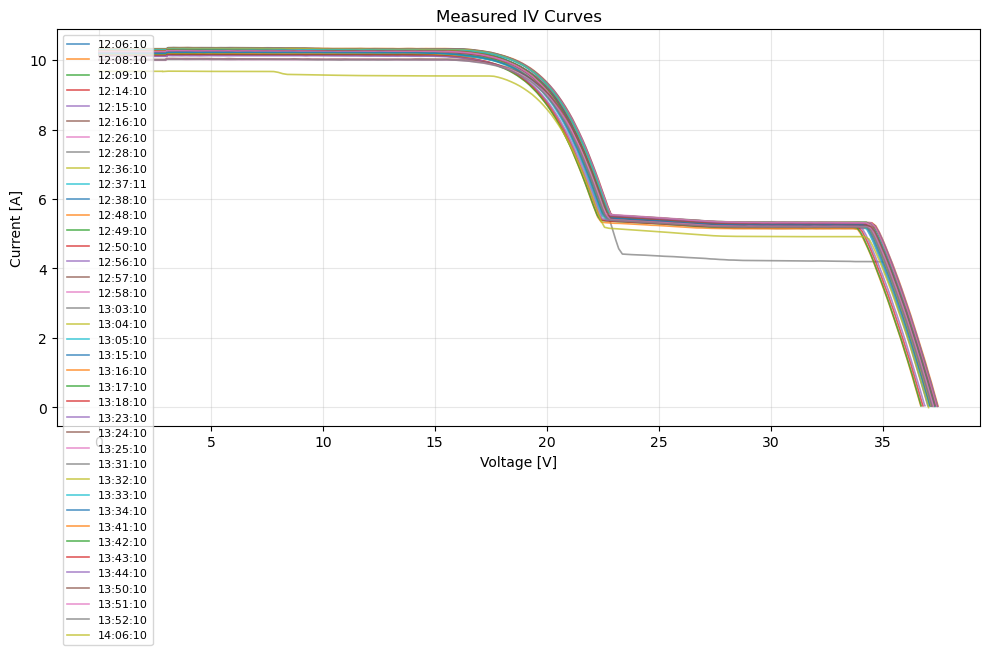

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in iv_valid.iterrows():
    V = row["Voltage_array"]
    I = row["Current_array"]

    ax.plot(
        V,
        I,
        linewidth=1.2,
        alpha=0.75,
        label=row["Date_Time"].strftime("%H:%M:%S") if pd.notna(row["Date_Time"]) else None
    )

ax.set_xlabel("Voltage [V]")
ax.set_ylabel("Current [A]")
ax.set_title("Measured IV Curves")
ax.grid(True, alpha=0.3)

# If you have many curves, the legend may be crowded
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

In [6]:
# Load the CEC module database from pvlib/SAM
cec_modules = pvlib.pvsystem.retrieve_sam("CECMod")

# Your module name
query = "LG320N1K-A5"

# CEC/SAM names often replace "-" with "_" and include manufacturer names
query_norm = query.replace("-", "_").upper()

matches = [
    name for name in cec_modules.columns
    if query_norm in name.upper().replace("-", "_")
]

print("Matches found:")
for m in matches:
    print(m)

# Select the first match
module_name = matches[0]
module_data = cec_modules[module_name]

print("\nSelected module:")
print(module_name)

print("\nModule data:")
print(module_data)

Matches found:
LG_Electronics_Inc__LG320N1K_A5

Selected module:
LG_Electronics_Inc__LG320N1K_A5

Module data:
Technology            Mono-c-Si
Bifacial                      0
STC                     320.346
PTC                       294.7
A_c                       1.649
Length                    1.662
Width                     0.992
N_s                          60
I_sc_ref                  10.19
V_oc_ref                   40.8
I_mp_ref                   9.62
V_mp_ref                   33.3
alpha_sc               0.002038
beta_oc                -0.10608
T_NOCT                     47.7
a_ref                  1.476693
I_L_ref               10.200071
I_o_ref                     0.0
R_s                    0.307043
R_sh_ref              310.65448
Adjust                 4.687218
gamma_r                  -0.357
BIPV                          N
Version       SAM 2018.11.11 r2
Date                   1/3/2019
Name: LG_Electronics_Inc__LG320N1K_A5, dtype: object


In [7]:
# IV fitting:
row_iloc = 0   # choose which IV curve to simulate
row = ivdata.iloc[row_iloc]

N_s = 60
N_modules = 1
N_byp = 2

n_rows = 6
n_cols = 10

# Bottom-left physical cell:
# row 5, col 0, if row 0 is top and col 0 is left
shaded_cell_index = 5 * n_cols + 0

print("Shaded cell index:", shaded_cell_index)

md = module_data.copy()

N_s_cec = int(float(md["N_s"]))
I_sc_ref = float(md["I_sc_ref"])
V_oc_ref = float(md["V_oc_ref"])
I_mp_ref = float(md["I_mp_ref"])
V_mp_ref = float(md["V_mp_ref"])
alpha_sc = float(md["alpha_sc"])
beta_oc = float(md["beta_oc"])
a_ref = float(md["a_ref"])
I_L_ref = float(md["I_L_ref"])
I_o_ref = float(md["I_o_ref"])
R_s_ref = float(md["R_s"])
R_sh_ref = float(md["R_sh_ref"])
Adjust = float(md["Adjust"])

if I_o_ref <= 0 or not np.isfinite(I_o_ref):
    I_o_ref = (I_L_ref - V_oc_ref / R_sh_ref) / np.expm1(V_oc_ref / a_ref)
    print(f"Estimated I_o_ref = {I_o_ref:.4e} A")
else:
    print(f"Using CEC I_o_ref = {I_o_ref:.4e} A")

Shaded cell index: 50
Using CEC I_o_ref = 1.0086e-11 A


In [8]:
G_unshaded = float(row["Irradiance_61"])

shade_pct = float(row["Shade_Percentage"])
shade_frac = np.clip(shade_pct / 100.0, 0.0, 1.0)

# If Shade_Percentage = 49, shaded cell gets 51% irradiance
G_shaded = G_unshaded * (1.0 - shade_frac)

# Use Middle_Temp for most cells
T_unshaded = float(row["Middle_Temp"])

# Use observed shaded cell temperature for the shaded cell
T_shaded = float(row["Observed_Temp of Shaded Cell"])

print("Date_Time:", row["Date_Time"])
print("Unshaded irradiance:", G_unshaded)
print("Shaded irradiance:", G_shaded)
print("Shade percentage:", shade_pct)
print("Unshaded cell temp:", T_unshaded)
print("Shaded cell temp:", T_shaded)

Date_Time: 2025-09-14T12:06:10
Unshaded irradiance: 989.21
Shaded irradiance: 504.49710000000005
Shade percentage: 49.0
Unshaded cell temp: 44.11791
Shaded cell temp: 82.4


In [9]:
IL_unshaded, I0_unshaded, Rs_module_unshaded, Rsh_module_unshaded, nNsVth_unshaded = pvlib.pvsystem.calcparams_cec(
    effective_irradiance=G_unshaded,
    temp_cell=T_unshaded,
    alpha_sc=alpha_sc,
    a_ref=a_ref,
    I_L_ref=I_L_ref,
    I_o_ref=I_o_ref,
    R_sh_ref=R_sh_ref,
    R_s=R_s_ref,
    Adjust=Adjust,
)

In [10]:
IL_shaded, I0_shaded, Rs_module_shaded, Rsh_module_shaded, nNsVth_shaded = pvlib.pvsystem.calcparams_cec(
    effective_irradiance=max(G_shaded, 1e-6),
    temp_cell=T_shaded,
    alpha_sc=alpha_sc,
    a_ref=a_ref,
    I_L_ref=I_L_ref,
    I_o_ref=I_o_ref,
    R_sh_ref=R_sh_ref,
    R_s=R_s_ref,
    Adjust=Adjust,
)

In [11]:
sd_unshaded = pvlib.pvsystem.singlediode(
    photocurrent=IL_unshaded,
    saturation_current=I0_unshaded,
    resistance_series=Rs_module_unshaded,
    resistance_shunt=Rsh_module_unshaded,
    nNsVth=nNsVth_unshaded,
)

v_oc_sim = float(sd_unshaded["v_oc"])

print("Estimated unshaded module Voc:", v_oc_sim)

Estimated unshaded module Voc: 38.6518778387981


In [12]:
Rs_cell_unshaded = Rs_module_unshaded / N_s
Rsh_cell_unshaded = Rsh_module_unshaded / N_s

Rs_cell_shaded = Rs_module_shaded / N_s
Rsh_cell_shaded = Rsh_module_shaded / N_s

# Thermal voltage at unshaded cell temperature
k_B = 1.380649e-23
q_e = 1.602176634e-19
T_K = T_unshaded + 273.15
Vth_cell = k_B * T_K / q_e

# SPICE diode ideality factor N
ideality_factor = nNsVth_unshaded / (N_s * Vth_cell)

# Use unshaded saturation current for the common SPICE diode model
saturation_current = I0_unshaded

print("IL unshaded:", IL_unshaded)
print("IL shaded:", IL_shaded)
print("Rs cell unshaded:", Rs_cell_unshaded)
print("Rsh cell unshaded:", Rsh_cell_unshaded)
print("Rsh cell shaded:", Rsh_cell_shaded)
print("SPICE ideality factor:", ideality_factor)
print("SPICE saturation current:", saturation_current)

IL unshaded: 10.126747588516295
IL shaded: 5.202156675180904
Rs cell unshaded: 0.005117383333333334
Rsh cell unshaded: 5.234050066888392
Rsh cell shaded: 10.26284326840861
SPICE ideality factor: 0.9579244607561156
SPICE saturation current: 2.0780120598826555e-10


In [13]:
cell_currents = np.full(N_s, IL_unshaded, dtype=float)
series_resistances = np.full(N_s, Rs_cell_unshaded, dtype=float)
shunt_resistances = np.full(N_s, Rsh_cell_unshaded, dtype=float)

# Apply shade to bottom-left cell
cell_currents[shaded_cell_index] = IL_shaded
series_resistances[shaded_cell_index] = Rs_cell_shaded
shunt_resistances[shaded_cell_index] = Rsh_cell_shaded

print("Cell photocurrent array:")
print(cell_currents)

Cell photocurrent array:
[10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759  5.20215668 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759]


In [15]:
spice_path = "docs/data/IVshaded"

breakdown_voltage = 12.0

# In module_to_netlist, v_bypass is used as BV in:
# .model sdby D (IS=1e-7 N=1 BV={v_bypass} IBV=20)
# So this is the reverse breakdown voltage of the bypass diode model.
v_bypass = 100.0

circuit_content, halfcut = module_to_netlist(
    path=spice_path,
    N_s=N_s,
    cell_currents=cell_currents,
    series_resistances=series_resistances,
    shunt_resistances=shunt_resistances,
    ideality_factor=ideality_factor,
    saturation_current=saturation_current,
    breakdown_voltage=breakdown_voltage,
    v_bypass=v_bypass,
    v_oc=v_oc_sim,
    TNOM=T_unshaded,
    circuit_name="solar_circuit",
)

print("halfcut:", halfcut)

All series interconnection of 60 solar cells
halfcut: False


In [17]:
circuit_file = os.path.join(spice_path, "solar_circuit.cir")

run_ngspice(
    ngpsice_path=spicepath,
    circuit_file=circuit_file,
)


Note: No compatibility mode selected!


Circuit: 

Doing analysis at TEMP = 44.117910 and TNOM = 44.117910


No. of Data Rows : 397
ASCII raw file "docs/data/IVshaded/solar_circuit.out"
ASCII raw file "docs/data/IVshaded/solar_circuit.txt"
ngspice-41 done


Note: v1: has no value, DC 0 assumed

Error: no such function as i,
    or i(d1) is not available.


In [18]:
voltage_spice, current_spice, df_spice = ngpsice_read_voltage_current_modules(spice_path)

# Depending on ngspice sign convention, source current may be negative.
# Flip so current is positive like your measured IV curves.
if len(df_spice) > 0 and np.nanmedian(df_spice["I"]) < 0:
    df_spice["I"] = -df_spice["I"]

df_spice.head()

,V,I
0,0.0,10.114580
1,0.1,10.114103
2,0.2,10.113625
3,0.3,10.113148
4,0.4,10.112671


In [19]:
if isinstance(row["Voltage"], str):
    V_meas = np.asarray(ast.literal_eval(row["Voltage"]), dtype=float)
else:
    V_meas = np.asarray(row["Voltage"], dtype=float)

if isinstance(row["Current"], str):
    I_meas = np.asarray(ast.literal_eval(row["Current"]), dtype=float)
else:
    I_meas = np.asarray(row["Current"], dtype=float)

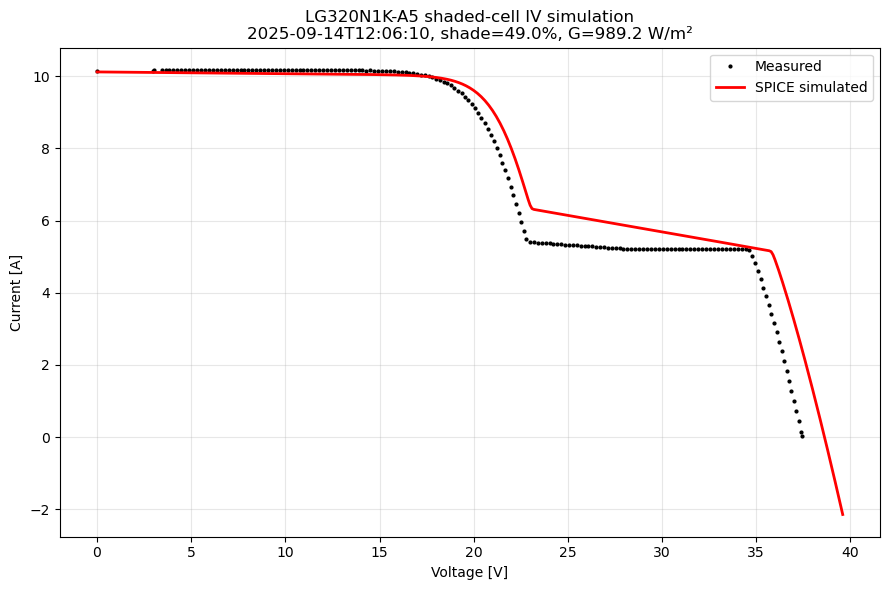

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    V_meas,
    I_meas,
    "k.",
    markersize=4,
    label="Measured",
)

ax.plot(
    df_spice["V"],
    df_spice["I"],
    "r-",
    linewidth=2,
    label="SPICE simulated",
)

ax.set_xlabel("Voltage [V]")
ax.set_ylabel("Current [A]")
ax.set_title(
    f"LG320N1K-A5 shaded-cell IV simulation\n"
    f"{row['Date_Time']}, shade={shade_pct:.1f}%, "
    f"G={G_unshaded:.1f} W/m²"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [23]:
#Read cell level IVs
def ngspice_read_cell_level_ivs(
    path,
    N_s=60,
    series_resistances=None,
    output_filename="solar_circuit.out",
    current_col="i(v1)",
    flip_module_current_if_negative=True,
):
    """
    Read ngspice ASCII raw output and reconstruct cell-level IV data.

    Parameters
    ----------
    path : str
        Folder containing the ngspice output file.
    N_s : int
        Number of cells in the module.
    series_resistances : float, list, or array, optional
        Per-cell series resistance values used in the SPICE netlist.
        If provided, cell current is calculated from voltage across each Rs.
        If None, only cell voltages are returned.
    output_filename : str
        Name of ngspice output file. Default is 'solar_circuit.out'.
    current_col : str
        Name of module current column in ngspice output. Usually 'i(v1)'.
    flip_module_current_if_negative : bool
        If True, flips module current sign when median current is negative.

    Returns
    -------
    df_cells_long : pandas.DataFrame
        Long-format cell-level IV dataframe with columns:
        sweep_V, module_V, module_I, cell, V_cell, V_diode, V_rs,
        and I_cell if series_resistances is provided.

    df_cells_wide : pandas.DataFrame
        Wide-format dataframe with one row per sweep point and columns:
        sweep_V, module_V, module_I, V_cell_0 ... V_cell_N,
        and optionally I_cell_0 ... I_cell_N.

    df_raw : pandas.DataFrame
        Raw ngspice variables as columns.

    Notes
    -----
    This assumes the standard non-halfcut pvspice node pattern:

        cell n:
            Rs_n from node 2n+1 to node 2n+2
            diode/Rp/current source from node 2n+2 to node 2n+3

        last cell ends at ground node 0.

    Therefore:
        V_cell_n = V(2n+1) - V(2n+3)
        V_diode_n = V(2n+2) - V(2n+3)
        V_rs_n = V(2n+1) - V(2n+2)

    For the last cell, V(2n+3) is replaced with ground, 0 V.
    """

    import os
    import numpy as np
    import pandas as pd

    output_file = os.path.join(path, output_filename)

    with open(output_file, "r") as f:
        lines = f.readlines()

    # ---------------------------------------------------------
    # Parse header information
    # ---------------------------------------------------------
    nvars = None
    npoints = None
    variables_start = None
    values_start = None

    for i, line in enumerate(lines):
        s = line.strip()

        if s.startswith("No. Variables:"):
            nvars = int(s.split(":")[1].strip())

        if s.startswith("No. Points:"):
            npoints = int(s.split(":")[1].strip())

        if s.startswith("Variables:"):
            variables_start = i + 1

        if s.startswith("Values:"):
            values_start = i + 1
            break

    if nvars is None:
        raise ValueError("Could not find 'No. Variables:' in ngspice output.")

    if variables_start is None:
        raise ValueError("Could not find 'Variables:' section in ngspice output.")

    if values_start is None:
        raise ValueError("Could not find 'Values:' section in ngspice output.")

    # ---------------------------------------------------------
    # Parse variable names
    # ---------------------------------------------------------
    var_names = []

    for line in lines[variables_start:values_start - 1]:
        parts = line.split()

        if len(parts) >= 2:
            var_names.append(parts[1])

    if len(var_names) != nvars:
        raise ValueError(
            f"Expected {nvars} variables, but parsed {len(var_names)} variable names."
        )

    # ---------------------------------------------------------
    # Parse values
    # ---------------------------------------------------------
    data = []
    current_point = []

    for line in lines[values_start:]:
        s = line.strip()

        if s == "":
            continue

        parts = s.split()

        # First line of each point looks like:
        #     0    0.000000e+00
        # Continuation lines look like:
        #          5.176018e-02
        if len(parts) >= 2:
            try:
                int(parts[0])
                value = float(parts[1])
            except ValueError:
                value = float(parts[0])
        else:
            value = float(parts[0])

        current_point.append(value)

        if len(current_point) == nvars:
            data.append(current_point)
            current_point = []

    df_raw = pd.DataFrame(data, columns=var_names)

    if npoints is not None and len(df_raw) != npoints:
        print(
            f"Warning: header says {npoints} points, "
            f"but parsed {len(df_raw)} points."
        )

    # ---------------------------------------------------------
    # Identify sweep/module voltage and current
    # ---------------------------------------------------------
    if "v(v-sweep)" in df_raw.columns:
        sweep_V = df_raw["v(v-sweep)"].to_numpy(dtype=float)
    else:
        sweep_V = df_raw.iloc[:, 0].to_numpy(dtype=float)

    if "v(1)" in df_raw.columns:
        module_V = df_raw["v(1)"].to_numpy(dtype=float)
    else:
        module_V = sweep_V.copy()

    if current_col in df_raw.columns:
        module_I = df_raw[current_col].to_numpy(dtype=float)
    else:
        matching_current_cols = [c for c in df_raw.columns if c.lower().startswith("i(")]
        if len(matching_current_cols) == 0:
            raise ValueError("Could not find any current column like i(v1).")
        current_col = matching_current_cols[-1]
        print(f"Using current column: {current_col}")
        module_I = df_raw[current_col].to_numpy(dtype=float)

    if flip_module_current_if_negative and np.nanmedian(module_I) < 0:
        module_I = -module_I

    # ---------------------------------------------------------
    # Expand series resistance array if provided
    # ---------------------------------------------------------
    calculate_cell_current = series_resistances is not None

    if calculate_cell_current:
        if np.isscalar(series_resistances):
            Rs_cells = np.full(N_s, float(series_resistances))
        else:
            Rs_cells = np.asarray(series_resistances, dtype=float)

            if len(Rs_cells) == 1:
                Rs_cells = np.full(N_s, float(Rs_cells[0]))
            elif len(Rs_cells) != N_s:
                raise ValueError(
                    f"series_resistances must have length 1 or N_s={N_s}, "
                    f"but got length {len(Rs_cells)}."
                )

    # ---------------------------------------------------------
    # Reconstruct cell voltages and currents
    # ---------------------------------------------------------
    df_cells_wide = pd.DataFrame()
    df_cells_wide["sweep_V"] = sweep_V
    df_cells_wide["module_V"] = module_V
    df_cells_wide["module_I"] = module_I

    long_rows = []

    n_points = len(df_raw)

    for n in range(N_s):
        start_node = 2 * n + 1
        after_rs_node = 2 * n + 2

        if n == N_s - 1:
            end_node = 0
        else:
            end_node = 2 * n + 3

        start_col = f"v({start_node})"
        after_rs_col = f"v({after_rs_node})"

        if start_col not in df_raw.columns:
            raise ValueError(f"Missing node voltage column {start_col}")

        if after_rs_col not in df_raw.columns:
            raise ValueError(f"Missing node voltage column {after_rs_col}")

        V_start = df_raw[start_col].to_numpy(dtype=float)
        V_after_rs = df_raw[after_rs_col].to_numpy(dtype=float)

        if end_node == 0:
            V_end = np.zeros(n_points)
        else:
            end_col = f"v({end_node})"

            if end_col not in df_raw.columns:
                raise ValueError(f"Missing node voltage column {end_col}")

            V_end = df_raw[end_col].to_numpy(dtype=float)

        # Full cell terminal voltage, including Rs
        V_cell = V_start - V_end

        # Diode/Rp/current-source junction voltage, excluding Rs
        V_diode = V_after_rs - V_end

        # Series resistor voltage, using netlist orientation
        V_rs = V_start - V_after_rs

        df_cells_wide[f"V_cell_{n}"] = V_cell
        df_cells_wide[f"V_diode_{n}"] = V_diode
        df_cells_wide[f"V_rs_{n}"] = V_rs

        if calculate_cell_current:
            # Positive PV current convention for your netlist
            I_cell = (V_after_rs - V_start) / Rs_cells[n]
            df_cells_wide[f"I_cell_{n}"] = I_cell
        else:
            I_cell = np.full(n_points, np.nan)

        for k in range(n_points):
            long_rows.append(
                {
                    "sweep_V": sweep_V[k],
                    "module_V": module_V[k],
                    "module_I": module_I[k],
                    "cell": n,
                    "V_cell": V_cell[k],
                    "V_diode": V_diode[k],
                    "V_rs": V_rs[k],
                    "I_cell": I_cell[k],
                }
            )

    df_cells_long = pd.DataFrame(long_rows)

    return df_cells_long, df_cells_wide, df_raw

In [24]:
df_cells_long, df_cells_wide, df_raw = ngspice_read_cell_level_ivs(
    path=spice_path,
    N_s=60,
    series_resistances=series_resistances,
    output_filename="solar_circuit.out",
)

/tmp/ipykernel_4824/2706883637.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_diode_{n}"] = V_diode
/tmp/ipykernel_4824/2706883637.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_rs_{n}"] = V_rs
/tmp/ipykernel_4824/2706883637.py:266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use 

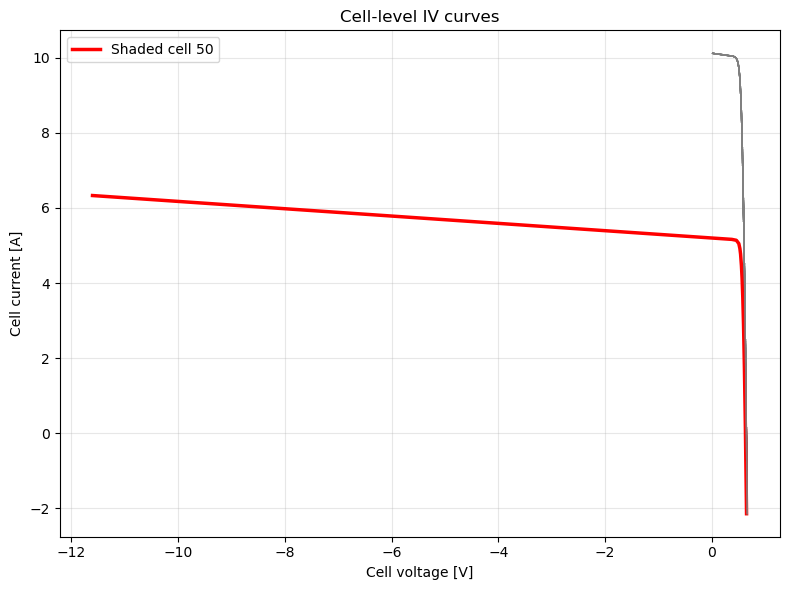

In [26]:
plt.figure(figsize=(8, 6))

for cell in range(60):
    d = df_cells_long[df_cells_long["cell"] == cell]

    if cell == shaded_cell_index:
        plt.plot(d["V_cell"], d["I_cell"], "r-", linewidth=2.5, label=f"Shaded cell {cell}")
    else:
        plt.plot(d["V_cell"], d["I_cell"], color="gray", alpha=0.25, linewidth=1)

plt.xlabel("Cell voltage [V]")
plt.ylabel("Cell current [A]")
plt.title("Cell-level IV curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
df_cells_wide["P_module"] = df_cells_wide["module_V"] * df_cells_wide["module_I"]

mpp_idx = df_cells_wide["P_module"].idxmax()

V_mpp_module = df_cells_wide.loc[mpp_idx, "module_V"]
I_mpp_module = df_cells_wide.loc[mpp_idx, "module_I"]
P_mpp_module = df_cells_wide.loc[mpp_idx, "P_module"]

print("Module MPP index:", mpp_idx)
print("Module Vmp [V]:", V_mpp_module)
print("Module Imp [A]:", I_mpp_module)
print("Module Pmp [W]:", P_mpp_module)

Module MPP index: 203
Module Vmp [V]: 20.30000000000002
Module Imp [A]: 9.47718296471149
Module Pmp [W]: 192.38681418364342


/tmp/ipykernel_4824/2485987322.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide["P_module"] = df_cells_wide["module_V"] * df_cells_wide["module_I"]


In [28]:
cell = shaded_cell_index

V_cell_mpp = df_cells_wide.loc[mpp_idx, f"V_cell_{cell}"]
I_cell_mpp = df_cells_wide.loc[mpp_idx, f"I_cell_{cell}"]

P_cell_elec_mpp = V_cell_mpp * I_cell_mpp

print("Shaded cell index:", cell)
print("Shaded cell voltage at module MPP [V]:", V_cell_mpp)
print("Shaded cell current at module MPP [A]:", I_cell_mpp)
print("Shaded cell electrical power at module MPP [W]:", P_cell_elec_mpp)

Shaded cell index: 50
Shaded cell voltage at module MPP [V]: -11.598702710461914
Shaded cell current at module MPP [A]: 6.329165404112872
Shaded cell electrical power at module MPP [W]: -73.41010792764574


In [29]:
A_module = float(module_data["A_c"])
A_cell = A_module / N_s

print("Module area [m^2]:", A_module)
print("Cell area [m^2]:", A_cell)

Module area [m^2]: 1.649
Cell area [m^2]: 0.027483333333333335


In [31]:
absorptance = 0.90

G_cell = G_shaded

P_solar_abs_cell = absorptance * G_cell * A_cell

# Total heat generation in the cell
# If P_cell_elec_mpp is positive, electrical power leaves the cell.
# If P_cell_elec_mpp is negative, electrical power is dissipated in the cell.
P_heat_cell = P_solar_abs_cell - P_cell_elec_mpp

# Reverse-bias-only electrical heating contribution
P_reverse_heat = max(0.0, -P_cell_elec_mpp)

print("Shaded cell irradiance [W/m^2]:", G_cell)
print("Absorbed solar power in shaded cell [W]:", P_solar_abs_cell)
print("Reverse-bias electrical heat [W]:", P_reverse_heat)
print("Total estimated cell heat generation [W]:", P_heat_cell)

T_amb = float(row["Amb_Temp"])
wind_speed = float(row["wind_speed"])

# Simple Faiman-like effective heat loss coefficient
# Units: W/m^2/K
h_eff = 25.0 + 6.84 * wind_speed

T_cell_est = T_amb + P_heat_cell / (h_eff * A_cell)

print("Ambient temperature [C]:", T_amb)
print("Wind speed [m/s]:", wind_speed)
print("Effective heat transfer coefficient [W/m^2/K]:", h_eff)
print("Estimated shaded cell temperature [C]:", T_cell_est)

Shaded cell irradiance [W/m^2]: 504.49710000000005
Absorbed solar power in shaded cell [W]: 12.478735768500002
Reverse-bias electrical heat [W]: 73.41010792764574
Total estimated cell heat generation [W]: 85.88884369614574
Ambient temperature [C]: 27.16882
Wind speed [m/s]: 3.404462
Effective heat transfer coefficient [W/m^2/K]: 48.28652008
Estimated shaded cell temperature [C]: 91.88925729075467


In [32]:
T_cell_measured = float(row["Observed_Temp of Shaded Cell"])

print("Measured shaded cell temperature [C]:", T_cell_measured)
print("Model error [C]:", T_cell_est - T_cell_measured)

Measured shaded cell temperature [C]: 82.4
Model error [C]: 9.489257290754665



Shaded cell results at module MPP
Shaded cell index: 50
Shaded cell voltage [V]: -11.598702710461914
Shaded cell current [A]: 6.329165404112872
Shaded cell electrical power [W]: -73.41010792764574
Shaded cell absorbed solar power [W]: 12.478735768500002
Shaded cell heat generation [W]: 85.88884369614574
Estimated shaded cell temperature [C]: 93.81440476011957
Measured shaded cell temperature [C]: 82.4
Temperature error [C]: 11.414404760119567

Hottest cells:


,cell,G_cell_Wm2,V_cell_MPP_V,I_cell_MPP_A,P_elec_cell_W,P_solar_abs_cell_W,P_heat_cell_W,T_cell_C,is_shaded
50,50,504.4971,-11.598703,6.329165,-73.410108,12.478736,85.888844,93.814405,True
40,40,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
42,42,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
41,41,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
46,46,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
44,44,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
43,43,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
47,47,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
58,58,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False
45,45,989.2100,0.585615,6.329165,3.706453,24.468109,20.761657,44.738648,False


/tmp/ipykernel_4824/3020408947.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


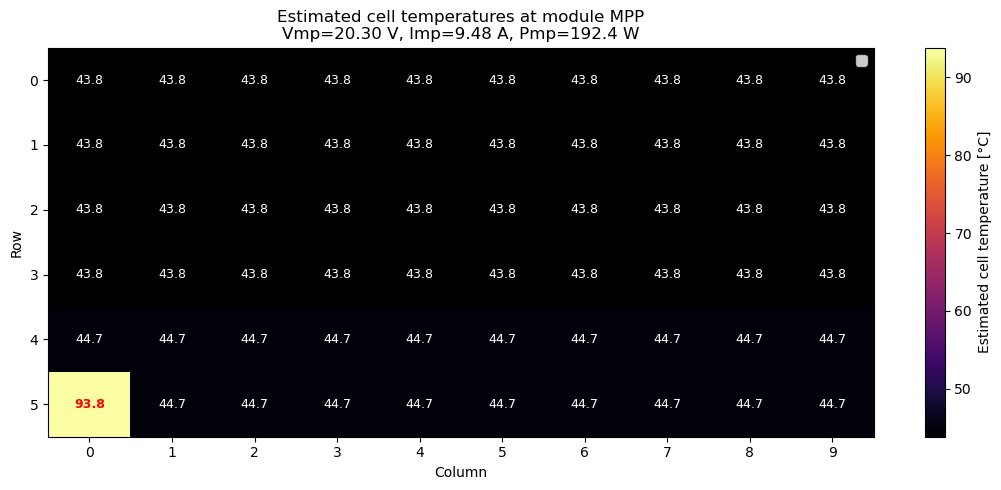

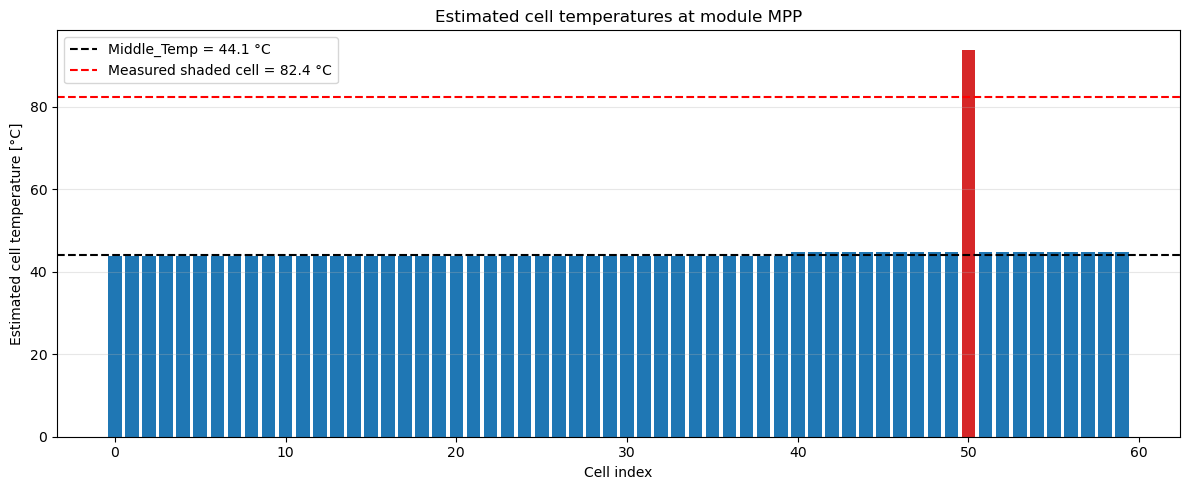

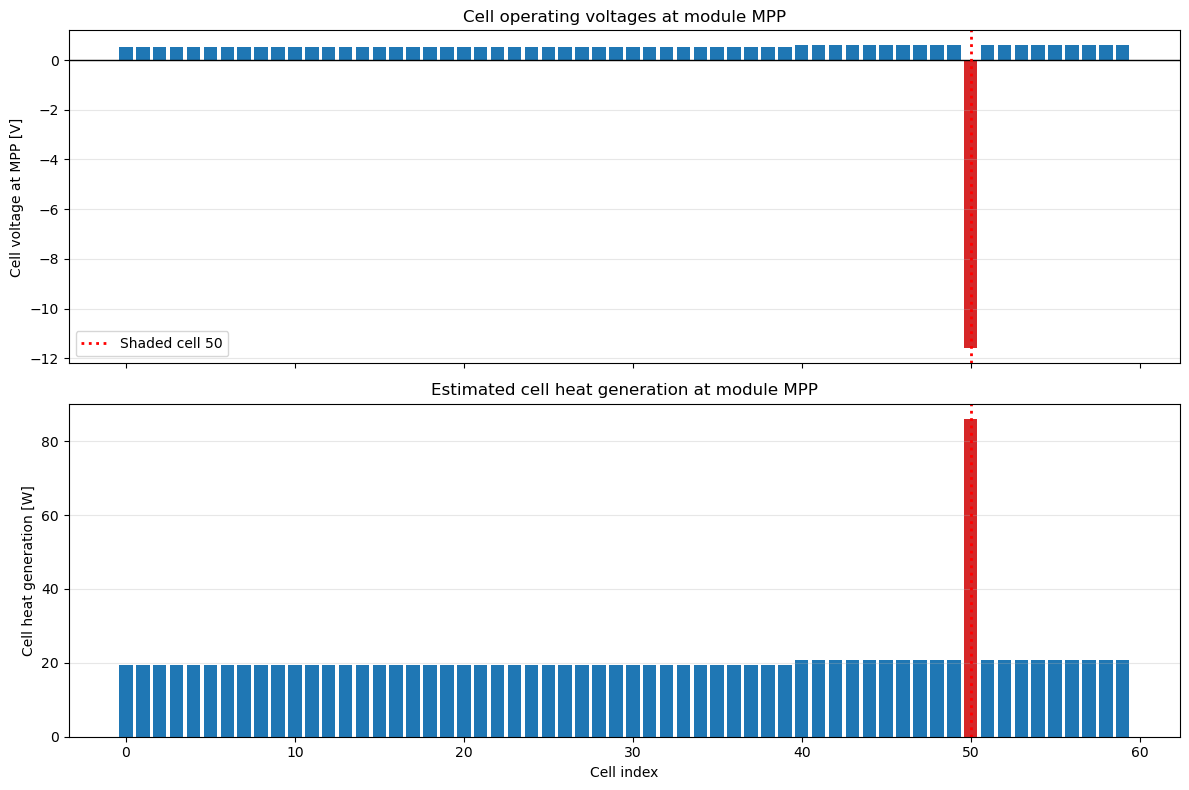

In [37]:
T_middle = float(row["Middle_Temp"])


# -----------------------------
# 2. Extract all cell operating points at module MPP
# -----------------------------
V_cells_mpp = np.array([
    df_cells_wide.loc[mpp_idx, f"V_cell_{c}"]
    for c in range(N_s)
], dtype=float)

I_cells_mpp = np.array([
    df_cells_wide.loc[mpp_idx, f"I_cell_{c}"]
    for c in range(N_s)
], dtype=float)

# If cell currents are negative due to sign convention, flip them
if np.nanmedian(I_cells_mpp) < 0:
    I_cells_mpp = -I_cells_mpp

P_cells_elec_mpp = V_cells_mpp * I_cells_mpp

# -----------------------------
# 3. Assign irradiance to each cell
# -----------------------------
G_cells = np.full(N_s, G_unshaded, dtype=float)
G_cells[shaded_cell_index] = G_shaded

# -----------------------------
# 4. Convert electrical/solar power to heat
# -----------------------------
P_solar_abs_cells = absorptance * G_cells * A_cell

# Heat generation:
# Positive P_elec means cell delivers electrical power, reducing heat.
# Negative P_elec means cell consumes electrical power, increasing heat.
P_heat_cells = P_solar_abs_cells - P_cells_elec_mpp

# Use unshaded cells as reference for Middle_Temp
unshaded_mask = np.ones(N_s, dtype=bool)
unshaded_mask[shaded_cell_index] = False

P_heat_unshaded_mean = np.mean(P_heat_cells[unshaded_mask])

# Estimate each cell temperature relative to Middle_Temp
T_cells = T_middle + (P_heat_cells - P_heat_unshaded_mean) / (h_eff * A_cell)

# -----------------------------
# 5. Print shaded-cell operating point and thermal result
# -----------------------------
V_shaded_mpp = V_cells_mpp[shaded_cell_index]
I_shaded_mpp = I_cells_mpp[shaded_cell_index]
P_elec_shaded_mpp = P_cells_elec_mpp[shaded_cell_index]
P_heat_shaded = P_heat_cells[shaded_cell_index]
T_shaded_est = T_cells[shaded_cell_index]

print("\nShaded cell results at module MPP")
print("Shaded cell index:", shaded_cell_index)
print("Shaded cell voltage [V]:", V_shaded_mpp)
print("Shaded cell current [A]:", I_shaded_mpp)
print("Shaded cell electrical power [W]:", P_elec_shaded_mpp)
print("Shaded cell absorbed solar power [W]:", P_solar_abs_cells[shaded_cell_index])
print("Shaded cell heat generation [W]:", P_heat_shaded)
print("Estimated shaded cell temperature [C]:", T_shaded_est)

if "Observed_Temp of Shaded Cell" in row.index:
    T_measured_shaded = float(row["Observed_Temp of Shaded Cell"])
    print("Measured shaded cell temperature [C]:", T_measured_shaded)
    print("Temperature error [C]:", T_shaded_est - T_measured_shaded)

# -----------------------------
# 6. Create summary dataframe
# -----------------------------
df_cell_temps = pd.DataFrame({
    "cell": np.arange(N_s),
    "G_cell_Wm2": G_cells,
    "V_cell_MPP_V": V_cells_mpp,
    "I_cell_MPP_A": I_cells_mpp,
    "P_elec_cell_W": P_cells_elec_mpp,
    "P_solar_abs_cell_W": P_solar_abs_cells,
    "P_heat_cell_W": P_heat_cells,
    "T_cell_C": T_cells,
})

df_cell_temps["is_shaded"] = False
df_cell_temps.loc[df_cell_temps["cell"] == shaded_cell_index, "is_shaded"] = True

print("\nHottest cells:")
display(df_cell_temps.sort_values("T_cell_C", ascending=False).head(10))

# -----------------------------
# 7. Plot 6 x 10 cell temperature heatmap
# -----------------------------
n_rows = 6
n_cols = 10

T_cells_2d = T_cells.reshape(n_rows, n_cols)

fig, ax = plt.subplots(figsize=(11, 5))

im = ax.imshow(
    T_cells_2d,
    cmap="inferno",
    aspect="auto",
    origin="upper"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Estimated cell temperature [°C]")

ax.set_title(
    f"Estimated cell temperatures at module MPP\n"
    f"Vmp={V_mpp_module:.2f} V, Imp={I_mpp_module:.2f} A, "
    f"Pmp={P_mpp_module:.1f} W"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))

# Add temperature labels to each cell
for r in range(n_rows):
    for c in range(n_cols):
        cell_idx = r * n_cols + c

        text_color = "red" if cell_idx == shaded_cell_index else "white"
        fontweight = "bold" if cell_idx == shaded_cell_index else "normal"

        ax.text(
            c,
            r,
            f"{T_cells_2d[r, c]:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
            fontweight=fontweight,
        )


ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# -----------------------------
# 8. Bar plot of all cell temperatures
# -----------------------------
cell_numbers = np.arange(N_s)

fig, ax = plt.subplots(figsize=(12, 5))

colors = np.array(["tab:blue"] * N_s)
colors[shaded_cell_index] = "tab:red"

ax.bar(cell_numbers, T_cells, color=colors)

ax.axhline(
    T_middle,
    color="k",
    linestyle="--",
    linewidth=1.5,
    label=f"Middle_Temp = {T_middle:.1f} °C"
)

if "Observed_Temp of Shaded Cell" in row.index:
    ax.axhline(
        T_measured_shaded,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Measured shaded cell = {T_measured_shaded:.1f} °C"
    )

ax.set_xlabel("Cell index")
ax.set_ylabel("Estimated cell temperature [°C]")
ax.set_title("Estimated cell temperatures at module MPP")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 9. Cell voltage and heat plots at MPP
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].bar(cell_numbers, V_cells_mpp, color=colors)
axes[0].axhline(0, color="k", linewidth=1)
axes[0].set_ylabel("Cell voltage at MPP [V]")
axes[0].set_title("Cell operating voltages at module MPP")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(cell_numbers, P_heat_cells, color=colors)
axes[1].set_xlabel("Cell index")
axes[1].set_ylabel("Cell heat generation [W]")
axes[1].set_title("Estimated cell heat generation at module MPP")
axes[1].grid(True, axis="y", alpha=0.3)

for ax in axes:
    ax.axvline(
        shaded_cell_index,
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Shaded cell {shaded_cell_index}"
    )

axes[0].legend()

plt.tight_layout()
plt.show()